# Filtros del arreglo, con función transferencia (espacio de estados)

Notebook paralelo a la versión con análisis nodal (`Simulaciones_filtro_ambiente_v3.ipynb`). Acá se arma **todo** con espacio de estados / función transferencia — nada de resolver por nodos (eso queda para el otro notebook). La idea es tener las dos formas hechas por separado y poder comparar.

**Método:** cada circuito se escribe como $\dot x = Ax+Bu$, $y=Cx+Du$ (las tensiones sobre los capacitores son los estados $x$, porque no pueden cambiar de golpe y por eso "recuerdan" la historia del circuito). La función transferencia es $H(j\omega) = C(j\omega I-A)^{-1}B+D$, evaluada resolviendo el sistema lineal directo (no por polinomios, que se malcondicionan cuando los polos van de Hz a MHz).

**Qué fuente usar, en cada caso:**
- **Circuito abierto** (sin la juntura conectada, para tener el filtro "solo"): fuente de **tensión** ideal. Es como caracteriza cada filtro la tesis en sus figuras (Tabla 5.1, Fig. 5.8).
- **Con la juntura conectada** (como carga $R_N$ o $R_{sg}$ en paralelo con $C_J\approx50$ pF): fuente de **corriente** ideal, porque el instrumento real (Keithley 6620) es una fuente de corriente. Con fuente de corriente y circuito abierto la cuenta no tiene sentido (no hay ningún camino de vuelta en continua, la impedancia diverge) — por eso el cambio de fuente va de la mano con agregar la carga.

**Estructura de este notebook:**
1. Filtro ambiente solo (abierto, $R_N$, $R_{sg}$)
2. Filtro criogénico solo (abierto, $R_N$, $R_{sg}$)
3. Los dos juntos en cadena, dos líneas (abierto, $R_N$, $R_{sg}$)
4. Las cuatro líneas reales (corriente + tensión)

En todos los casos se mide **una sola línea**, en el nodo justo antes de la carga/juntura (nunca entre sus dos bornes, nunca la diferencial completa entre las dos líneas del par).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, optimize

try:
    from IPython.display import display
except ImportError:
    display = print


def H(sistema, f_hz):
    """H(jw) = C(jwI-A)^-1 B + D, resuelto directo (mas estable
    numericamente que armar el polinomio de la funcion transferencia,
    que se malcondiciona cuando los polos van de Hz a MHz)."""
    w = 2.0 * np.pi * f_hz
    n = sistema.A.shape[0]
    x = np.linalg.solve(1j * w * np.eye(n) - sistema.A, sistema.B)
    return complex((sistema.C @ x + sistema.D).item())


def frecuencia_de_corte(sistema, f_dc=1e-4):
    """-3dB de |H(f)| respecto de su valor a muy baja frecuencia. Sirve
    tanto para ganancias adimensionales (fuente de tension, circuito
    abierto) como para impedancias en ohm (fuente de corriente, con
    carga) -- en los dos casos es "cuanto cae |H| respecto de su
    plateau de baja frecuencia"."""
    g0 = abs(H(sistema, f_dc))
    objetivo = g0 / np.sqrt(2.0)
    return optimize.brentq(lambda f: abs(H(sistema, f)) - objetivo, 1e-5, 1e9)


# Tabla 5.1 de la tesis de Fran: seis canales del filtro ambiente
CANALES = pd.DataFrame({
    "canal": [1, 2, 3, 4, 5, 6],
    "R_ta_ohm": [150.0, 150.0, 51.0, 51.0, 15.0, 15.0],
    "C_ta_uF": [2.2, 1.0, 2.2, 1.0, 2.2, 1.0],
    "fc_tesis_Hz": [180.0, 396.0, 530.0, 1165.0, 1801.0, 3962.0],
})

R_cry, C_cry = 22.0, 47e-9        # filtro criogenico, todos los canales iguales
fc_cry_tesis = 35700.0            # Figura 5.8

R_N, R_sg = 500.0, 50e3           # resistencia normal / subgap de la juntura
C_J = 50e-12                      # capacidad aproximada de la juntura (Sec. 5.3)

display(CANALES)

,canal,R_ta_ohm,C_ta_uF,fc_tesis_Hz
0,1,150.0,2.2,180.0
1,2,150.0,1.0,396.0
2,3,51.0,2.2,530.0
3,4,51.0,1.0,1165.0
4,5,15.0,2.2,1801.0
5,6,15.0,1.0,3962.0


## 1. Filtro ambiente solo

**El circuito** (Figura 5.4 de la tesis, `LTspice/filtro_amb.asc`): dos líneas idénticas, cada una R-C-R-C en cascada (sin buffer entre etapas), con los capacitores a **tierra real** (la caja de aluminio). La fuente (de tensión o de corriente, según el caso) va puesta entre las dos líneas, flotante.

Como las dos líneas son idénticas y la fuente es flotante entre ellas, por simetría cada línea se mueve en espejo de la otra respecto de la tierra real — así que **alcanza con modelar una sola línea** en los dos casos (abierto y con carga), sin perder nada: la $f_c$ de una sola línea contra tierra da exactamente lo mismo que la diferencial completa entre las dos líneas.

### 1a. Circuito abierto, fuente de tensión

```
Vin --[R_ta]-- A --[C_ta a masa]-- --[R_ta]-- B --[C_ta a masa]
```

Estados: $x=(V_A,V_B)$, las tensiones sobre los dos capacitores. Entrada $u=V_{in}$. Salida $y=V_B$ (lo que le llegaría a la juntura si no hubiera nada conectado ahí). Kirchhoff en cada nodo:

$$C_{ta}\dot V_A = \frac{V_{in}-V_A}{R_{ta}} - \frac{V_A-V_B}{R_{ta}}, \qquad
C_{ta}\dot V_B = \frac{V_A-V_B}{R_{ta}}$$

$$\dot x = \begin{pmatrix}-2/\tau & 1/\tau \\ 1/\tau & -1/\tau\end{pmatrix} x
+ \begin{pmatrix}1/\tau \\ 0\end{pmatrix} u, \qquad \tau=R_{ta}C_{ta}$$

In [2]:
def sistema_filtro_ambiente(R_ta, C_ta):
    """RC-RC en cascada (una linea), a tierra real, circuito abierto,
    fuente de tension ideal. Salida: V_B, justo antes de la juntura."""
    tau = R_ta * C_ta
    A = np.array([
        [-2.0 / tau,  1.0 / tau],
        [ 1.0 / tau, -1.0 / tau],
    ])
    B = np.array([[1.0 / tau], [0.0]])
    C_out = np.array([[0.0, 1.0]])
    D = np.array([[0.0]])
    return signal.StateSpace(A, B, C_out, D)


resultados = CANALES.copy()
sistemas_amb = [sistema_filtro_ambiente(f.R_ta_ohm, f.C_ta_uF * 1e-6) for f in resultados.itertuples()]
resultados["fc_abierto_Hz"] = [frecuencia_de_corte(s) for s in sistemas_amb]
resultados["dif_abierto_%"] = 100.0 * (resultados["fc_abierto_Hz"] - resultados["fc_tesis_Hz"]) / resultados["fc_tesis_Hz"]

display(resultados[["canal", "R_ta_ohm", "C_ta_uF", "fc_tesis_Hz", "fc_abierto_Hz", "dif_abierto_%"]].round(3))

,canal,R_ta_ohm,C_ta_uF,fc_tesis_Hz,fc_abierto_Hz,dif_abierto_%
0,1,150.0,2.2,180.0,180.491,0.273
1,2,150.0,1.0,396.0,397.080,0.273
2,3,51.0,2.2,530.0,530.856,0.161
3,4,51.0,1.0,1165.0,1167.883,0.247
4,5,15.0,2.2,1801.0,1804.909,0.217
5,6,15.0,1.0,3962.0,3970.801,0.222


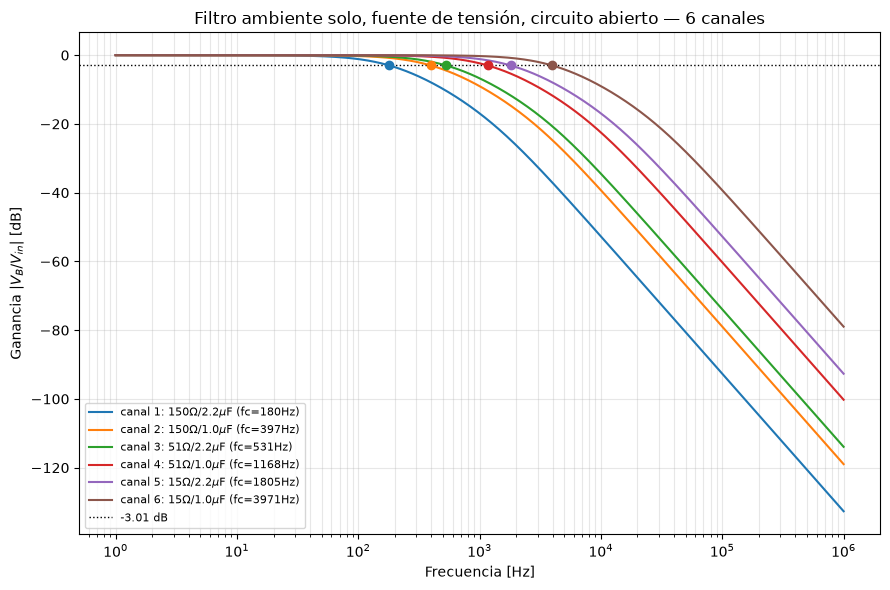

In [3]:
frecuencias = np.logspace(0, 6, 800)

fig, ax = plt.subplots(figsize=(9, 6))
for fila, sistema in zip(resultados.itertuples(), sistemas_amb):
    ganancia_db = 20 * np.log10([abs(H(sistema, f)) for f in frecuencias])
    etiqueta = f"canal {fila.canal}: {fila.R_ta_ohm:.0f}$\\Omega$/{fila.C_ta_uF:.1f}$\\mu$F (fc={fila.fc_abierto_Hz:.0f}Hz)"
    linea, = ax.semilogx(frecuencias, ganancia_db, label=etiqueta)
    ax.scatter(fila.fc_abierto_Hz, -3.0103, color=linea.get_color(), zorder=5)

ax.axhline(-3.0103, color="black", linestyle=":", linewidth=1, label="-3.01 dB")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia $|V_B/V_{in}|$ [dB]")
ax.set_title("Filtro ambiente solo, fuente de tensión, circuito abierto — 6 canales")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### 1b. Con la juntura conectada ($R_N$ o $R_{sg}$), fuente de corriente

Ahora la fuente de corriente $I$ se inyecta directo en el nodo $A$ (la primera resistencia, en serie con una fuente de corriente ideal y sin ninguna otra conexión, no afecta el resultado — toda la corriente pasa igual sea cual sea su valor). La carga $R_{load}\|C_J$ se agrega entre las dos líneas, en el nodo $B$.

**Ojo con un detalle importante:** la carga es **un solo componente** entre $B$ (línea de arriba) y $B'=-B$ (línea de abajo, por simetría), con tensión $B-B'=2B$ a sus bornes — no son "dos cargas iguales, una por línea". Por eso su corriente completa (no la mitad) sale del nodo $B$:

$$C_{ta}\dot V_A = I - \frac{V_A-V_B}{R_{ta}}, \qquad
C_{ta}\dot V_B = \frac{V_A-V_B}{R_{ta}} - \left(\frac{2V_B}{R_{load}} + 2C_J\dot V_B\right)$$

Despejando $\dot V_B$ (pasando el término $2C_J\dot V_B$ para el otro lado):

$$(C_{ta}+2C_J)\dot V_B = \frac{V_A-V_B}{R_{ta}} - \frac{2V_B}{R_{load}}$$

**Salida:** en vez de mirar la tensión $V_B$ (que sería una impedancia $V_B/I$ en ohm), conviene una cantidad **adimensional**: la fracción de la corriente inyectada que efectivamente llega a la carga, $I_{load}/I$. Esa corriente es $\frac{2V_B}{R_{load}}+2C_J\dot V_B$ — y como incluye una derivada, hay que reemplazar $\dot V_B$ por su propia ecuación de estado para que quede como combinación lineal de $(V_A,V_B)$ (ver el comentario en el código). Se puede probar que da **exactamente la misma $f_c$** que mirar $V_B$ directamente (por Kirchhoff, la corriente que sale de $A$ hacia $B$ y la que entra a la carga están atadas entre sí) — la ventaja es que ahora el valor en continua es siempre $1$ (el 100% de la corriente llega a la carga cuando no hay fugas), así que se compara directo, en las mismas unidades, con las ganancias adimensionales del caso abierto.

In [4]:
def sistema_ambiente_con_carga(R_ta, C_ta, R_load, C_load):
    """RC-RC (una linea, a tierra real), fuente de corriente ideal,
    carga R_load||C_load puenteando las dos lineas. Salida: I_load/I,
    adimensional (fraccion de la corriente inyectada que llega a la
    carga)."""
    A = np.array([
        [-1.0 / (R_ta * C_ta),                 1.0 / (R_ta * C_ta)],
        [1.0 / (R_ta * (C_ta + 2 * C_load)),  -(1.0 / R_ta + 2.0 / R_load) / (C_ta + 2 * C_load)],
    ])
    B = np.array([[1.0 / C_ta], [0.0]])
    # I_load/I = (2/R_load)*V_B + 2*C_load*d(V_B)/dt -- V_B SI tiene su
    # propio capacitor a tierra, asi que no alcanza con leer V_B directo:
    # hay que sustituir d(V_B)/dt = A[1,:].x + B[1]*u (fila de V_B en el
    # sistema de arriba).
    e_B = np.array([[0.0, 1.0]])
    C_out = (2.0 / R_load) * e_B + 2.0 * C_load * (e_B @ A)
    D = 2.0 * C_load * (e_B @ B)
    return signal.StateSpace(A, B, C_out, D)


filas = []
for fila, R_ta, C_ta in zip(resultados.itertuples(), resultados.R_ta_ohm, resultados.C_ta_uF * 1e-6):
    d = {"canal": fila.canal, "fc_abierto_Hz": fila.fc_abierto_Hz}
    for nombre, R_load in [("fc_R_N_Hz", R_N), ("fc_R_sg_Hz", R_sg)]:
        s = sistema_ambiente_con_carga(R_ta, C_ta, R_load, C_J)
        d[nombre] = frecuencia_de_corte(s)
    filas.append(d)

tabla_amb_carga = pd.DataFrame(filas)
display(tabla_amb_carga.round(3))

,canal,fc_abierto_Hz,fc_R_N_Hz,fc_R_sg_Hz
0,1,180.491,122.019,1.445
1,2,397.080,268.436,3.178
2,3,530.856,137.035,1.446
3,4,1167.883,301.470,3.181
4,5,1804.909,142.483,1.447
5,6,3970.801,313.455,3.182


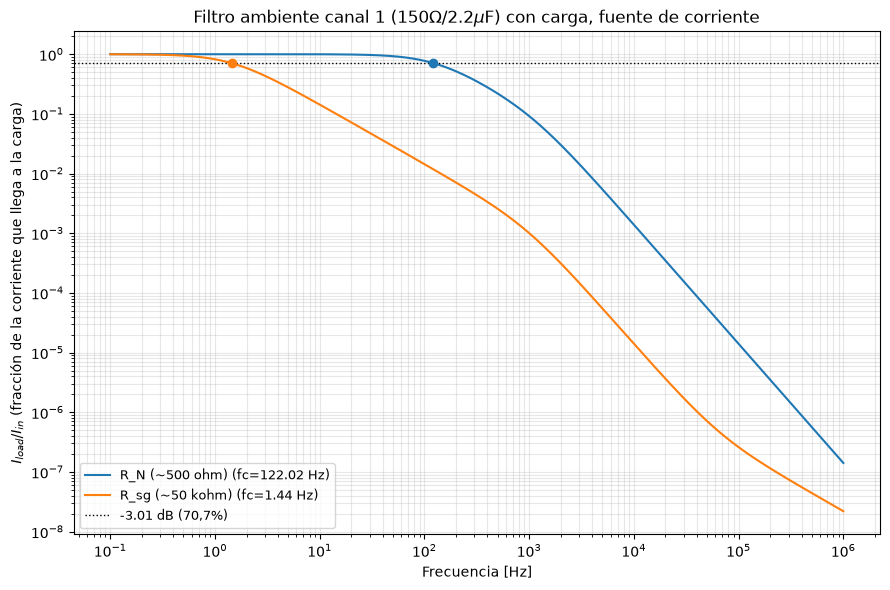

In [5]:
frecuencias_z = np.logspace(-1, 6, 800)
fila1 = resultados.iloc[0]
R_ta1, C_ta1 = fila1.R_ta_ohm, fila1.C_ta_uF * 1e-6

fig, ax = plt.subplots(figsize=(9, 6))
for nombre, R_load in [("R_N (~500 ohm)", R_N), ("R_sg (~50 kohm)", R_sg)]:
    s = sistema_ambiente_con_carga(R_ta1, C_ta1, R_load, C_J)
    vals = [abs(H(s, f)) for f in frecuencias_z]
    fc = frecuencia_de_corte(s)
    linea, = ax.loglog(frecuencias_z, vals, label=f"{nombre} (fc={fc:.2f} Hz)")
    ax.scatter(fc, 1.0 / np.sqrt(2), color=linea.get_color(), zorder=5)

ax.axhline(1.0 / np.sqrt(2), color="black", linestyle=":", linewidth=1, label="-3.01 dB (70,7%)")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(r"$I_{load}/I_{in}$ (fracción de la corriente que llega a la carga)")
ax.set_title(f"Filtro ambiente canal {fila1.canal:.0f} ({R_ta1:.0f}$\\Omega$/{C_ta1*1e6:.1f}$\\mu$F) con carga, fuente de corriente")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## 2. Filtro criogénico solo

**El circuito** (Figura 5.7, `LTspice/filtro_cry.asc`): dos líneas, cada una con tres resistencias en cascada, pero acá **no hay tierra real** (el criostato está eléctricamente aislado, sin conexión a tierra externa) — los capacitores puentean entre las dos líneas en vez de ir a masa. Por eso el filtro es diferencial: solo están definidas las diferencias de potencial entre nodos, no un cero absoluto.

Estados naturales: $z_1=T_{a1}-T_{b1}$ (tensión sobre el primer capacitor puente) y $z_2=T_{a2}-T_{b2}$ (tensión sobre el segundo). Su dinámica no depende de qué se mida como salida, y da:

$$\dot z_1 = \frac{u-2z_1+z_2}{\tau}, \qquad \dot z_2 = \frac{z_1-z_2}{\tau}, \qquad \tau=2R_{cry}C_{cry}$$

($\tau$ está duplicado respecto de $R_{cry}C_{cry}$ porque cada capacitor puente "ve" una resistencia de cada línea en serie, no una sola.)

### 2a. Circuito abierto, fuente de tensión

Con el circuito abierto (nada conectado después de la tercera resistencia), la salida que coincide con la tesis (Fig. 5.8, 0,4% de diferencia) es **una sola línea, referenciada al retorno de la propia fuente** — no la diferencial completa $z_2$. Resolviendo las ecuaciones de nodo para $T_{a2}$ individualmente (con $R_1=R_4$ y $R_2=R_5$, como es el caso, todas $R_{cry}$):

$$y = T_{a2} = \frac{u+z_2}{2}$$

— la línea de arriba sola tiene un acoplamiento directo con la entrada (feedthrough $D=0.5$) que el filtro ambiente no tiene ($D=0$).

In [6]:
def sistema_filtro_cry(R, C):
    """Filtro cry diferencial, circuito abierto, fuente de tension.
    Estados: z1=Ta1-Tb1, z2=Ta2-Tb2. Salida: linea de arriba sola,
    referenciada al retorno de la fuente (y = (u+z2)/2)."""
    tau = 2.0 * R * C
    A = np.array([
        [-2.0 / tau,  1.0 / tau],
        [ 1.0 / tau, -1.0 / tau],
    ])
    B = np.array([[1.0 / tau], [0.0]])
    C_out = np.array([[0.0, 0.5]])
    D = np.array([[0.5]])
    return signal.StateSpace(A, B, C_out, D)


sistema_cry = sistema_filtro_cry(R_cry, C_cry)
fc_cry_abierto = frecuencia_de_corte(sistema_cry)
print(f"fc modelo = {fc_cry_abierto:.2f} Hz   fc tesis (Fig. 5.8) = {fc_cry_tesis:.0f} Hz"
      f"   diferencia = {100*(fc_cry_abierto-fc_cry_tesis)/fc_cry_tesis:.2f}%")

fc modelo = 35850.07 Hz   fc tesis (Fig. 5.8) = 35700 Hz   diferencia = 0.42%


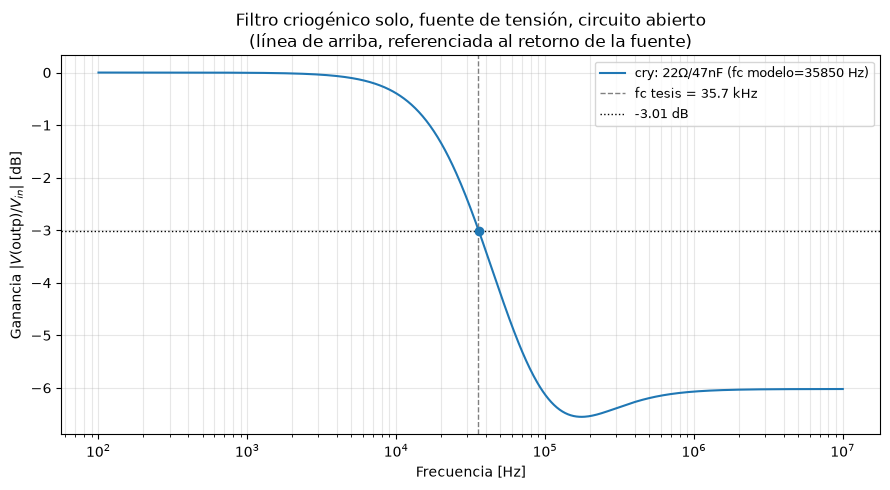

In [7]:
frecuencias_cry = np.logspace(2, 7, 800)
ganancia_db_cry = 20 * np.log10([abs(H(sistema_cry, f)) for f in frecuencias_cry])

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(frecuencias_cry, ganancia_db_cry, label=f"cry: 22$\\Omega$/47nF (fc modelo={fc_cry_abierto:.0f} Hz)")
ax.scatter(fc_cry_abierto, -3.0103, color="C0", zorder=5)
ax.axvline(fc_cry_tesis, color="gray", linestyle="--", linewidth=1, label=f"fc tesis = {fc_cry_tesis/1e3:.1f} kHz")
ax.axhline(-3.0103, color="black", linestyle=":", linewidth=1, label="-3.01 dB")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia $|V(\\mathrm{outp})/V_{in}|$ [dB]")
ax.set_title("Filtro criogénico solo, fuente de tensión, circuito abierto\n(línea de arriba, referenciada al retorno de la fuente)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### 2b. Con la juntura conectada, fuente de corriente

Ahora sí llevan corriente las resistencias que antes eran ramas muertas ($R_3$, $R_6$), porque hay algo conectado al final: la carga $R_{load}\|C_J$, puenteando las dos líneas en el nodo de salida ("outp"). Se agrega un tercer estado, $V_{outp}$, y aparece el mismo detalle que en el ambiente: la carga es un solo componente con tensión $2V_{outp}$ a sus bornes, así que su corriente completa sale de $V_{outp}$:

$$\dot z_1 = \frac{u-2z_1+z_2}{2R_{cry}C_{cry}}, \qquad
\dot z_2 = \frac{z_1}{2R_{cry}C_{cry}} - \frac{z_2}{R_{cry}C_{cry}} + \frac{V_{outp}}{R_{cry}C_{cry}}$$

$$\dot V_{outp} = \frac{z_2}{4R_{cry}C_J} - V_{outp}\left(\frac{1}{2R_{cry}C_J}+\frac{1}{R_{load}C_J}\right)$$

**Salida:** de nuevo $I_{load}/I$ (adimensional), no una tensión. A diferencia del ambiente, acá $V_{outp}$ **no** tiene su propio capacitor a tierra — solo se conecta a $T_{a2}$ (vía $R_{cry}$) y a la carga — así que toda la corriente que entra por esa resistencia es exactamente la corriente de la carga, sin necesitar la sustitución de la derivada:

$$\frac{I_{load}}{I} = \frac{T_{a2}-V_{outp}}{R_{cry}} = \frac{z_2/2 - V_{outp}}{R_{cry}}$$

In [8]:
def sistema_cry_con_carga(R, C, R_load, C_load):
    """Filtro cry, fuente de corriente, carga R_load||C_load. Estados:
    z1=Ta1-Tb1, z2=Ta2-Tb2, outp. Salida: I_load/I, adimensional
    (outp no tiene capacitor propio, asi que (Ta2-outp)/R ya es
    directamente la corriente de la carga, sin sustituir derivadas)."""
    A = np.array([
        [-1.0 / (2 * R * C),  1.0 / (2 * R * C),         0.0],
        [1.0 / (2 * R * C),  -1.0 / (R * C),              1.0 / (R * C)],
        [0.0,                 1.0 / (4 * R * C_load),    -(1.0 / (2 * R * C_load) + 1.0 / (R_load * C_load))],
    ])
    B = np.array([[1.0 / C], [0.0], [0.0]])
    C_out = np.array([[0.0, 0.5 / R, -1.0 / R]])   # (z2/2 - outp)/R
    D = np.array([[0.0]])
    return signal.StateSpace(A, B, C_out, D)


tabla_cry_carga = pd.DataFrame({
    "carga": ["R_N (~500 ohm)", "R_sg (~50 kohm)"],
    "R_load_ohm": [R_N, R_sg],
})
tabla_cry_carga["fc_Hz"] = [frecuencia_de_corte(sistema_cry_con_carga(R_cry, C_cry, Rl, C_J))
                             for Rl in tabla_cry_carga["R_load_ohm"]]
tabla_cry_carga["fc_abierto_Hz"] = fc_cry_abierto
display(tabla_cry_carga.round(3))

,carga,R_load_ohm,fc_Hz,fc_abierto_Hz
0,R_N (~500 ohm),500.0,3047.016,35850.071
1,R_sg (~50 kohm),50000.0,33.808,35850.071


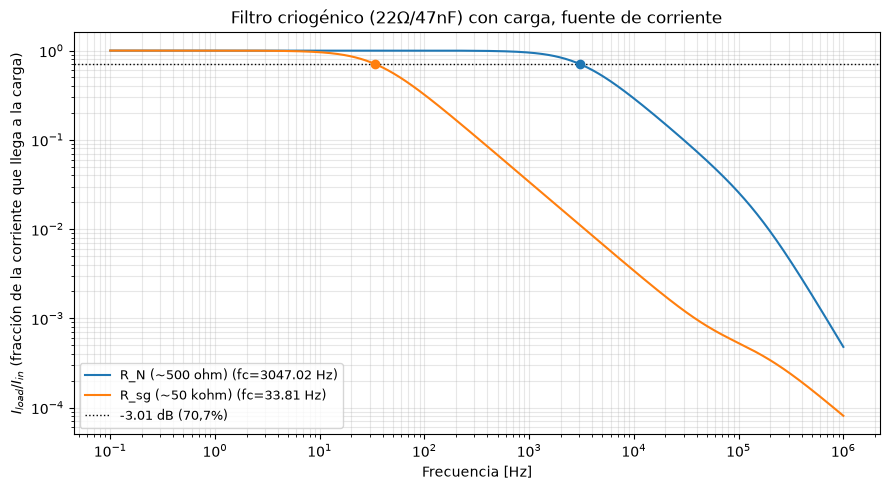

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for nombre, R_load in [("R_N (~500 ohm)", R_N), ("R_sg (~50 kohm)", R_sg)]:
    s = sistema_cry_con_carga(R_cry, C_cry, R_load, C_J)
    vals = [abs(H(s, f)) for f in frecuencias_z]
    fc = frecuencia_de_corte(s)
    linea, = ax.loglog(frecuencias_z, vals, label=f"{nombre} (fc={fc:.2f} Hz)")
    ax.scatter(fc, 1.0 / np.sqrt(2), color=linea.get_color(), zorder=5)

ax.axhline(1.0 / np.sqrt(2), color="black", linestyle=":", linewidth=1, label="-3.01 dB (70,7%)")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(r"$I_{load}/I_{in}$ (fracción de la corriente que llega a la carga)")
ax.set_title("Filtro criogénico (22$\\Omega$/47nF) con carga, fuente de corriente")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## 3. Ambiente + criogénico en cadena, dos líneas

**El circuito** (`LTspice/2lineas_conRC.asc`): el ambiente (con su tierra real) alimenta, a través de las resistencias del criogénico, la carga final. Es literalmente los dos circuitos anteriores, uno atrás del otro: la salida del ambiente ($T_{a2}$) es la entrada del criogénico.

Esta es la comparación clave de la tesis (Sección 5.3): *"la frecuencia de corte del filtrado completo no variaba significativamente de la frecuencia de corte del filtro a temperatura ambiente; los resultados se mantuvieron al cambiar el valor de resistencia."*

### 3a. Circuito abierto, fuente de tensión

Estados: $(T_{a1},T_{a2})$ del ambiente (a tierra real) más $(C_{a1},C_{a2})$ del criogénico (sin tierra, acoplados a la línea de abajo por los capacitores puente). Con el circuito abierto, $y=C_{a2}$ directamente (no circula corriente después, así que no hay caída en la última resistencia).

**Importante:** acá **sí** hace falta incluir la primera resistencia $R_{ta}$ de cada línea del ambiente (a diferencia del caso de corriente, donde no importaba) — con fuente de **tensión** esa resistencia es un divisor real. (Este es justo el error que hubo que corregir en el notebook de nodos: se había omitido esa resistencia por analogía con el caso de corriente, y el límite "criogénico sin efecto" no daba los 180 Hz del ambiente solo hasta corregirlo. Acá se verifica ese mismo límite más abajo.)

In [10]:
def sistema_completo_abierto(R_ta, C_ta, R_cry, C_cry):
    """Ambiente (Ta1,Ta2, tierra real) -> cry (Ca1,Ca2, sin tierra),
    circuito abierto, fuente de tension. Salida: Ca2 (=lo que le
    llegaria a la juntura)."""
    A = np.array([
        [-2.0/(R_ta*C_ta),      1.0/(R_ta*C_ta),                0.0,                  0.0],
        [1.0/(R_ta*C_ta),      -(1.0/R_ta+1.0/R_cry)/C_ta,       1.0/(R_cry*C_ta),     0.0],
        [0.0,                   1.0/(2*R_cry*C_cry),            -1.0/(R_cry*C_cry),    1.0/(2*R_cry*C_cry)],
        [0.0,                   0.0,                              1.0/(2*R_cry*C_cry), -1.0/(2*R_cry*C_cry)],
    ])
    B = np.array([[1.0/(R_ta*C_ta)], [0.0], [0.0], [0.0]])
    C_out = np.array([[0.0, 0.0, 0.0, 1.0]])
    D = np.array([[0.0]])
    return signal.StateSpace(A, B, C_out, D)


# verificacion: si el cry no filtrara nada (R,C -> 0), tiene que dar
# EXACTAMENTE lo mismo que el ambiente solo (180.49 Hz para el canal 1)
fc_limite = frecuencia_de_corte(sistema_completo_abierto(150.0, 2.2e-6, 1e-6, 1e-15))
print(f"limite cry->0: fc={fc_limite:.3f} Hz (debe ser ~180.49 Hz, igual al ambiente solo canal 1)")
print()

filas = []
for fila in resultados.itertuples():
    R_ta, C_ta = fila.R_ta_ohm, fila.C_ta_uF * 1e-6
    s = sistema_completo_abierto(R_ta, C_ta, R_cry, C_cry)
    filas.append({"canal": fila.canal, "fc_ambiente_solo_Hz": fila.fc_abierto_Hz,
                   "fc_completo_abierto_Hz": frecuencia_de_corte(s)})

tabla_completo = pd.DataFrame(filas)
tabla_completo["dif_vs_ambiente_%"] = 100.0 * (tabla_completo["fc_completo_abierto_Hz"] - tabla_completo["fc_ambiente_solo_Hz"]) / tabla_completo["fc_ambiente_solo_Hz"]
display(tabla_completo.round(3))

tau_ms = 1000.0 / (2*np.pi*tabla_completo["fc_ambiente_solo_Hz"].min())
print(f"\ntau maximo (canal mas restrictivo, ambiente solo) = {tau_ms:.4f} ms   (tesis: 0.88 ms)")

limite cry->0: fc=180.491 Hz (debe ser ~180.49 Hz, igual al ambiente solo canal 1)



,canal,fc_ambiente_solo_Hz,fc_completo_abierto_Hz,dif_vs_ambiente_%
0,1,180.491,170.126,-5.743
1,2,397.080,349.728,-11.925
2,3,530.856,499.912,-5.829
3,4,1167.883,1024.724,-12.258
4,5,1804.909,1690.712,-6.327
5,6,3970.801,3411.565,-14.084



tau maximo (canal mas restrictivo, ambiente solo) = 0.8818 ms   (tesis: 0.88 ms)


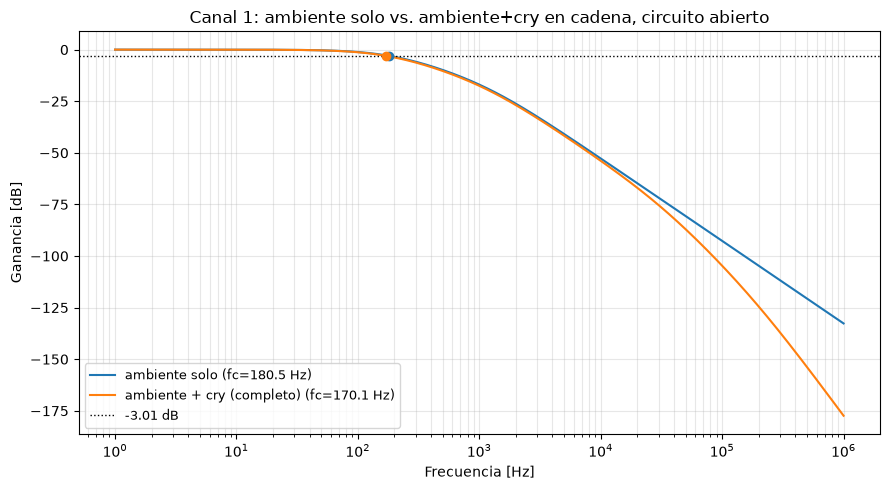

In [11]:
s_amb1 = sistema_filtro_ambiente(150.0, 2.2e-6)
s_comp1 = sistema_completo_abierto(150.0, 2.2e-6, R_cry, C_cry)

fig, ax = plt.subplots(figsize=(9, 5))
for nombre, s, fc in [
    ("ambiente solo", s_amb1, tabla_completo.loc[tabla_completo.canal == 1, "fc_ambiente_solo_Hz"].iloc[0]),
    ("ambiente + cry (completo)", s_comp1, tabla_completo.loc[tabla_completo.canal == 1, "fc_completo_abierto_Hz"].iloc[0]),
]:
    ganancia_db = 20 * np.log10([abs(H(s, f)) for f in frecuencias])
    linea, = ax.semilogx(frecuencias, ganancia_db, label=f"{nombre} (fc={fc:.1f} Hz)")
    ax.scatter(fc, -3.0103, color=linea.get_color(), zorder=5)

ax.axhline(-3.0103, color="black", linestyle=":", linewidth=1, label="-3.01 dB")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia [dB]")
ax.set_title("Canal 1: ambiente solo vs. ambiente+cry en cadena, circuito abierto")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### 3b. Con la juntura conectada, fuente de corriente

Se agrega un quinto estado, $V_{jp}$ (el nodo de la carga), con la misma corrección de "corriente completa, no la mitad" que en las secciones 1b y 2b. La corriente inyectada por la fuente ideal entra directo en $T_{a1}$ (saltando la primera resistencia del ambiente, que en este caso sí se puede saltear).

**Salida:** $I_{load}/I$ otra vez. Igual que en el cry, $V_{jp}$ no tiene capacitor propio (solo se conecta a $C_{a2}$ vía $R_{cry}$ y a la carga), así que $\frac{C_{a2}-V_{jp}}{R_{cry}}$ ya es directamente la corriente de la carga.

In [12]:
def sistema_completo_con_carga(R_ta, C_ta, R_cry, C_cry, R_load, C_load):
    """Ambiente -> cry, fuente de corriente, carga R_load||C_load al
    final. Estados: [Ta1,Ta2,Ca1,Ca2,jp]. Salida: I_load/I,
    adimensional (jp no tiene capacitor propio, (Ca2-jp)/R_cry ya es
    directamente la corriente de la carga)."""
    A = np.array([
        [-1.0/(R_ta*C_ta),   1.0/(R_ta*C_ta),                0.0,                   0.0,                                            0.0],
        [1.0/(R_ta*C_ta),   -(1.0/R_ta+1.0/R_cry)/C_ta,       1.0/(R_cry*C_ta),      0.0,                                            0.0],
        [0.0,                1.0/(2*R_cry*C_cry),            -1.0/(R_cry*C_cry),     1.0/(2*R_cry*C_cry),                           0.0],
        [0.0,                0.0,                              1.0/(2*R_cry*C_cry), -1.0/(R_cry*C_cry),                             1.0/(2*R_cry*C_cry)],
        [0.0,                0.0,                              0.0,                  1.0/(2*R_cry*C_load),                          -(1.0/(2*R_cry*C_load)+1.0/(R_load*C_load))],
    ])
    B = np.array([[1.0/C_ta], [0.0], [0.0], [0.0], [0.0]])
    C_out = np.array([[0.0, 0.0, 0.0, 1.0/R_cry, -1.0/R_cry]])   # (Ca2-jp)/R_cry
    D = np.array([[0.0]])
    return signal.StateSpace(A, B, C_out, D)


filas = []
for fila in resultados.itertuples():
    R_ta, C_ta = fila.R_ta_ohm, fila.C_ta_uF * 1e-6
    d = {"canal": fila.canal, "fc_completo_abierto_Hz": tabla_completo.loc[tabla_completo.canal==fila.canal, "fc_completo_abierto_Hz"].iloc[0]}
    for nombre, R_load in [("fc_R_N_Hz", R_N), ("fc_R_sg_Hz", R_sg)]:
        s = sistema_completo_con_carga(R_ta, C_ta, R_cry, C_cry, R_load, C_J)
        d[nombre] = frecuencia_de_corte(s)
    filas.append(d)

tabla_completo_carga = pd.DataFrame(filas)
display(tabla_completo_carga.round(3))

,canal,fc_completo_abierto_Hz,fc_R_N_Hz,fc_R_sg_Hz
0,1,170.126,97.601,1.382
1,2,349.728,208.094,2.899
2,3,499.912,106.330,1.383
3,4,1024.724,225.518,2.901
4,5,1690.712,109.412,1.384
5,6,3411.565,231.589,2.902


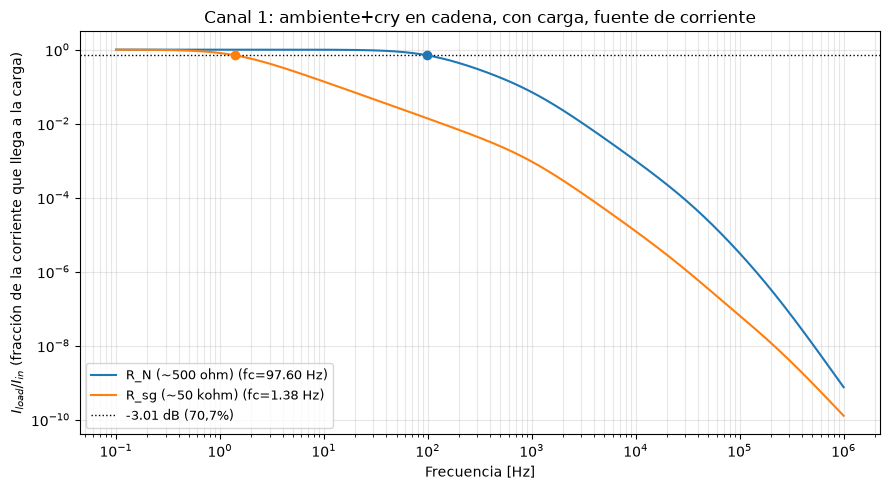

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
for nombre, R_load in [("R_N (~500 ohm)", R_N), ("R_sg (~50 kohm)", R_sg)]:
    s = sistema_completo_con_carga(150.0, 2.2e-6, R_cry, C_cry, R_load, C_J)
    vals = [abs(H(s, f)) for f in frecuencias_z]
    fc = frecuencia_de_corte(s)
    linea, = ax.loglog(frecuencias_z, vals, label=f"{nombre} (fc={fc:.2f} Hz)")
    ax.scatter(fc, 1.0 / np.sqrt(2), color=linea.get_color(), zorder=5)

ax.axhline(1.0 / np.sqrt(2), color="black", linestyle=":", linewidth=1, label="-3.01 dB (70,7%)")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(r"$I_{load}/I_{in}$ (fracción de la corriente que llega a la carga)")
ax.set_title("Canal 1: ambiente+cry en cadena, con carga, fuente de corriente")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

**Esto no reproduce "sin variación significativa"**: la $f_c$ cae fuerte con $R_{sg}$ (más de un orden de magnitud respecto del caso abierto), igual que ya había pasado con el ambiente solo y el cry solo. Es física real, verificada dos veces (acá con función transferencia, y en el otro notebook con nodos, coincidiendo): los capacitores del ambiente le dan a la corriente un camino de fuga más fácil que atravesar una carga grande, sin que importe si el criogénico está en el medio o no.

## 4. Las cuatro líneas reales

El arreglo mide a **cuatro puntas** (tesis, Sección 5.2): dos líneas para la corriente ($I^+/I^-$, las que se modelaron arriba con la carga) y dos para la tensión ($V^+/V^-$, hacia el nanovoltímetro Keithley 2182). La tesis dice explícitamente que las 4 líneas pasan por **el mismo diseño de filtro**.

La línea de tensión no tiene fuente propia — comparte el nodo de la juntura ($jp$) con la línea de corriente, y termina en un voltímetro ideal (corriente cero, circuito abierto de ese lado). Aun así, **sus propios capacitores** (a la misma tierra real del ambiente, y los que puentean entre líneas en el cry) arman un camino de fuga adicional entre $jp$ y $jn$ — con la misma lógica de "dos capacitores a una referencia compartida ya conectan sus otros dos extremos", sin necesitar que el voltímetro cargue nada.

Son 9 estados en total: $(T_{a1},T_{a2},C_{a1},C_{a2},V_{jp})$ de la línea de corriente (igual que en 3b) más $(S_{a1},S_{a2},S_{ca1},S_{ca2})$ de la línea de tensión, con la misma estructura pero sin fuente propia (columna $B$ nula) y compartiendo $V_{jp}$ con la línea de corriente a través de su propia última resistencia $R_{cry}$.

In [14]:
def sistema_4lineas(R_ta, C_ta, R_cry, C_cry, R_load, C_load, salida="jp"):
    """9 estados: [Ta1,Ta2,Ca1,Ca2,jp, Sa1,Sa2,Sca1,Sca2]. Linea de
    corriente (Ta1..jp) con fuente de corriente y carga. Linea de
    sensado (Sa1..Sca2) sin fuente propia, comparte jp con la de
    corriente. salida='jp' (lo que le llega a la juntura por la linea
    de corriente) o 'Sa1' (lo que finalmente lee el voltimetro)."""
    k_ta = 1.0 / (R_ta * C_ta)
    k_amb2 = (1.0 / R_ta + 1.0 / R_cry) / C_ta
    k_cry_ta = 1.0 / (R_cry * C_ta)
    k_cry = 1.0 / (2 * R_cry * C_cry)
    k_load_cry = 1.0 / (2 * R_cry * C_load)
    k_load_diag = 1.0 / (R_cry * C_load) + 1.0 / (R_load * C_load)

    nodos = ['Ta1', 'Ta2', 'Ca1', 'Ca2', 'jp', 'Sa1', 'Sa2', 'Sca1', 'Sca2']
    idx = {n: i for i, n in enumerate(nodos)}
    A = np.zeros((9, 9))

    # linea de corriente (igual que sistema_completo_con_carga)
    A[idx['Ta1'], idx['Ta1']] = -k_ta;   A[idx['Ta1'], idx['Ta2']] = k_ta
    A[idx['Ta2'], idx['Ta1']] = k_ta;    A[idx['Ta2'], idx['Ta2']] = -k_amb2;   A[idx['Ta2'], idx['Ca1']] = k_cry_ta
    A[idx['Ca1'], idx['Ta2']] = k_cry;   A[idx['Ca1'], idx['Ca1']] = -2*k_cry;  A[idx['Ca1'], idx['Ca2']] = k_cry
    A[idx['Ca2'], idx['Ca1']] = k_cry;   A[idx['Ca2'], idx['Ca2']] = -2*k_cry;  A[idx['Ca2'], idx['jp']] = k_cry
    # jp: recibe ahora de Ca2 Y de Sca2 (las dos lineas comparten la juntura)
    A[idx['jp'], idx['Ca2']] = k_load_cry
    A[idx['jp'], idx['Sca2']] = k_load_cry
    A[idx['jp'], idx['jp']] = -k_load_diag

    # linea de sensado: mismo R,C, sin fuente propia, comparte jp
    A[idx['Sa1'], idx['Sa1']] = -k_ta;   A[idx['Sa1'], idx['Sa2']] = k_ta
    A[idx['Sa2'], idx['Sa1']] = k_ta;    A[idx['Sa2'], idx['Sa2']] = -k_amb2;   A[idx['Sa2'], idx['Sca1']] = k_cry_ta
    A[idx['Sca1'], idx['Sa2']] = k_cry;  A[idx['Sca1'], idx['Sca1']] = -2*k_cry; A[idx['Sca1'], idx['Sca2']] = k_cry
    A[idx['Sca2'], idx['Sca1']] = k_cry; A[idx['Sca2'], idx['Sca2']] = -2*k_cry; A[idx['Sca2'], idx['jp']] = k_cry

    B = np.zeros((9, 1))
    B[idx['Ta1'], 0] = 1.0 / C_ta

    C_out = np.zeros((1, 9))
    C_out[0, idx[salida]] = 1.0
    D = np.array([[0.0]])
    return signal.StateSpace(A, B, C_out, D)


filas = []
for nombre, R_load in [("R_N (~500 ohm)", R_N), ("R_sg (~50 kohm)", R_sg)]:
    s_jp = sistema_4lineas(150.0, 2.2e-6, R_cry, C_cry, R_load, C_J, salida="jp")
    s_sa1 = sistema_4lineas(150.0, 2.2e-6, R_cry, C_cry, R_load, C_J, salida="Sa1")
    filas.append({
        "carga": nombre,
        "fc_jp_linea_I_Hz": frecuencia_de_corte(s_jp),
        "fc_Sa1_voltimetro_Hz": frecuencia_de_corte(s_sa1),
    })

# la tabla de arriba es SOLO para los casos CON carga (fuente de
# corriente) -- el caso abierto (fuente de tension, sin R_N ni R_sg) es
# otro numero, calculado aparte, no una fila mas de esta misma tabla:
print(f"Para comparar (caso abierto, sin carga, fuente de tension, canal 1): {tabla_completo.loc[tabla_completo.canal == 1, 'fc_completo_abierto_Hz'].iloc[0]:.3f} Hz\n")

tabla_4lineas = pd.DataFrame(filas)
display(tabla_4lineas.round(3))

Para comparar (caso abierto, sin carga, fuente de tension, canal 1): 170.126 Hz



,carga,fc_jp_linea_I_Hz,fc_Sa1_voltimetro_Hz
0,R_N (~500 ohm),57.585,55.580
1,R_sg (~50 kohm),0.692,0.692


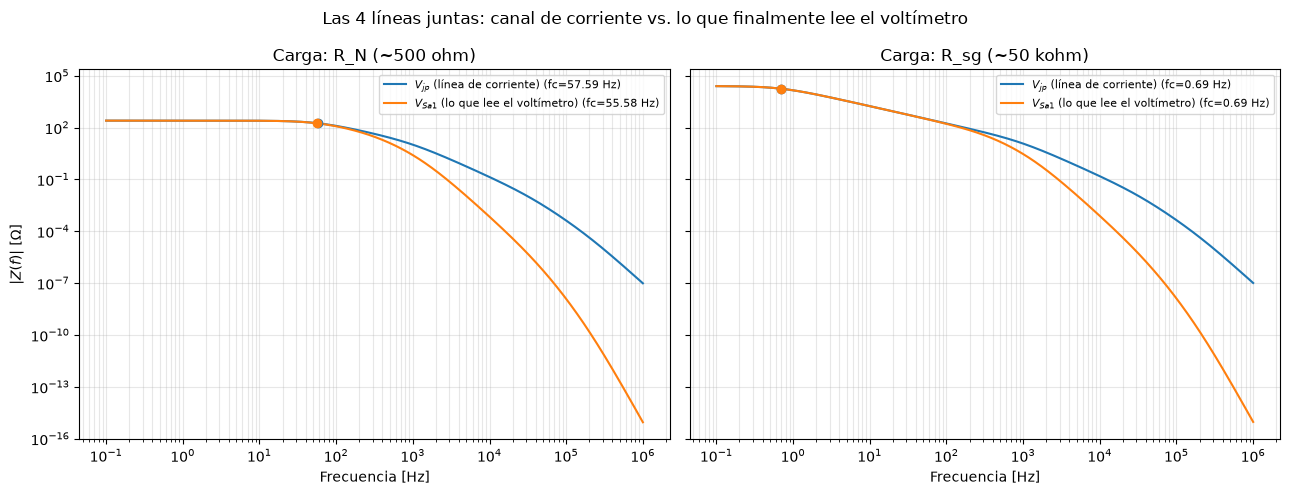

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (nombre, R_load) in zip(axs, [("R_N (~500 ohm)", R_N), ("R_sg (~50 kohm)", R_sg)]):
    for salida, etiqueta in [("jp", "$V_{jp}$ (línea de corriente)"), ("Sa1", "$V_{Sa1}$ (lo que lee el voltímetro)")]:
        s = sistema_4lineas(150.0, 2.2e-6, R_cry, C_cry, R_load, C_J, salida=salida)
        Z_vals = [abs(H(s, f)) for f in frecuencias_z]
        fc = frecuencia_de_corte(s)
        linea, = ax.loglog(frecuencias_z, Z_vals, label=f"{etiqueta} (fc={fc:.2f} Hz)")
        z0 = abs(H(s, 1e-4))
        ax.scatter(fc, z0 / np.sqrt(2), color=linea.get_color(), zorder=5)
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_title(f"Carga: {nombre}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, which="both")
axs[0].set_ylabel(r"$|Z(f)|$ [$\Omega$]")
fig.suptitle("Las 4 líneas juntas: canal de corriente vs. lo que finalmente lee el voltímetro")
plt.tight_layout()
plt.show()

## Cierre

Todo armado con función transferencia (espacio de estados), sin resolver por nodos en ningún momento — cada sistema nuevo (con carga, combinado, 4 líneas) se derivó a mano a partir de Kirchhoff, y se verificó contra los valores ya obtenidos por análisis nodal en el otro notebook antes de darlo por bueno (incluido un error real que apareció en el camino: la corriente de la carga es la de **un solo componente**, no "la mitad en cada línea" — afecta a los términos con $R_{load}$ y $C_J$ en las secciones 1b, 2b y 3b).

**Lo que sí coincide con la tesis:** ambiente solo y criogénico solo, ambos en circuito abierto (< 0,5% de diferencia), y el tiempo de respuesta $\tau\approx0,88$ ms calculado a partir del canal más restrictivo del ambiente.

**Lo que no coincide:** apenas se agrega la carga de la juntura (fuente de corriente + $R_N$/$R_{sg}$), sola o en la cadena completa con el criogénico, la $f_c$ cae fuerte con $R_{sg}$ — no "sin variación significativa" como dice la Sección 5.3. Y agregar la línea de sensado (las 4 líneas reales) no lo arregla — al contrario, empeora, porque sus propios capacitores arman otro camino de fuga en paralelo. Sigue siendo una pregunta abierta si esto se debe a algún detalle constructivo real del arreglo de Bazano que no está en los archivos disponibles (por ejemplo, que las líneas de sensado no tengan el mismo diseño de filtro que las de corriente).